# Fechando com Dados #001
## O pulso recente da economia brasileira

Neste projeto, vou analisar indicadores públicos recentes do **IBGE / SIDRA** para construir uma leitura simples do momento econômico brasileiro.

### Indicadores escolhidos neste episódio
- **IPCA**: variação mensal
- **Comércio**: variação mês contra mês imediatamente anterior
- **Serviços**: variação mês contra mês imediatamente anterior

### Observação metodológica
A **indústria** foi testada na exploração inicial, mas a tabela escolhida para este episódio não entregou um agregado nacional simples e consistente para a narrativa do projeto. Por isso, ela ficou **fora do escopo desta versão** do notebook.

### Objetivo
Transformar dados públicos recentes em um pequeno estudo exploratório, com foco em:
- prática de coleta e limpeza de dados
- leitura de séries temporais
- construção de narrativa analítica
- geração de material para portfólio e LinkedIn

## Pergunta central

**O que os indicadores mais recentes do IBGE sugerem sobre o pulso recente da economia brasileira?**

### Perguntas auxiliares
- Os três indicadores caminham juntos ou em ritmos diferentes?
- O comportamento recente sugere aceleração, desaceleração ou oscilação?
- Qual leitura inicial pode ser feita ao observar os últimos 12 períodos?

## Hipóteses iniciais

Antes de olhar os dados, vale registrar hipóteses de partida.

### Hipótese 1
Os indicadores não devem se mover na mesma direção o tempo todo.

### Hipótese 2
Comércio e serviços podem apresentar ritmos diferentes da inflação ao consumidor.

### Hipótese 3
A leitura do momento recente tende a ficar mais clara quando colocamos as séries lado a lado.

> Registrar hipóteses antes da análise ajuda a comparar expectativa e evidência.

## Preparação do ambiente

Nesta etapa vamos:
1. importar as bibliotecas
2. definir as tabelas e classificações
3. preparar a estrutura de coleta
4. organizar os arquivos do projeto

In [123]:
from pathlib import Path
from urllib.parse import quote
import json
import re

import requests
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [124]:
# Configuração do projeto
DATA_DIR = Path("dados_fechando_com_dados_epi1")
DATA_DIR.mkdir(exist_ok=True)

TABLES = {
    "ipca": 7060,
    "comercio": 8880,
    "servicos": 5906,
}

CLASSIFICATIONS = {
    "ipca": {},
    "comercio": {11046: 56734},  # Índice de volume de vendas no comércio varejista
    "servicos": {11046: 56726},  # Índice de volume de serviços
}

SERIES_LABELS = {
    "ipca": "IPCA - variação mensal (%)",
    "comercio": "Comércio - variação mensal (%)",
    "servicos": "Serviços - variação mensal (%)",
}

PERIODS = "last 12"
BRAZIL_CODE = 1

print("Pasta do projeto:", DATA_DIR.resolve())
print("Tabelas ativas:", TABLES)

Pasta do projeto: C:\Users\cco\OneDrive - Guanabara Diesel\0.Formação DSA\Z.Fechando com Dados\proj001\dados_fechando_com_dados_epi1
Tabelas ativas: {'ipca': 7060, 'comercio': 8880, 'servicos': 5906}


## Funções auxiliares de coleta

Vamos criar funções para:
- montar URLs da API do SIDRA
- buscar JSON da API
- salvar arquivos locais
- consultar metadados

A ideia é deixar o processo reaproveitável para os próximos episódios.

In [125]:
def sidra_values_url(table_id: int, periods: str = "last 12", brazil_code: int = 1,
                     variable: str = "allxp", classifications: dict | None = None) -> str:
    parts = [f"t/{table_id}"]

    if classifications:
        for class_id, cat_id in classifications.items():
            parts.append(f"c{class_id}/{cat_id}")

    parts.extend([
        f"n1/{brazil_code}",
        f"p/{quote(periods, safe='')}",
        f"v/{variable}",
        "h/n",
        "f/n",
    ])

    return "https://apisidra.ibge.gov.br/values/" + "/".join(parts)


def ibge_metadata_url(table_id: int) -> str:
    return f"https://servicodados.ibge.gov.br/api/v3/agregados/{table_id}/metadados"


def fetch_json(url: str):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    return response.json()


def save_json(data, file_path: Path):
    with file_path.open("w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

## Coleta dos dados

Agora vamos baixar:
- os valores brutos de cada tabela
- os metadados oficiais

Também vamos salvar tudo em arquivo para deixar o projeto auditável.

In [126]:
raw_dataframes = {}
metadata_dict = {}

for name, table_id in TABLES.items():
    print(f"Baixando {name}...")

    values_url = sidra_values_url(
        table_id=table_id,
        periods=PERIODS,
        brazil_code=BRAZIL_CODE,
        variable="allxp",
        classifications=CLASSIFICATIONS.get(name, {}),
    )

    print("URL:", values_url)

    values_json = fetch_json(values_url)
    df = pd.DataFrame(values_json)
    raw_dataframes[name] = df
    df.to_csv(DATA_DIR / f"{name}_raw.csv", index=False, encoding="utf-8-sig")

    metadata = fetch_json(ibge_metadata_url(table_id))
    metadata_dict[name] = metadata
    save_json(metadata, DATA_DIR / f"{name}_metadata.json")

print("Coleta concluída.")

Baixando ipca...
URL: https://apisidra.ibge.gov.br/values/t/7060/n1/1/p/last%2012/v/allxp/h/n/f/n
Baixando comercio...
URL: https://apisidra.ibge.gov.br/values/t/8880/c11046/56734/n1/1/p/last%2012/v/allxp/h/n/f/n
Baixando servicos...
URL: https://apisidra.ibge.gov.br/values/t/5906/c11046/56726/n1/1/p/last%2012/v/allxp/h/n/f/n
Coleta concluída.


## Inspeção inicial

Antes de limpar qualquer coisa, vale olhar os dados exatamente como chegaram.

Nesta etapa, observe:
- quantidade de linhas e colunas
- nomes das colunas
- presença de cabeçalho embutido
- formato da coluna de valores

In [127]:
for name, df in raw_dataframes.items():
    print("=" * 90)
    print(f"DATASET BRUTO: {name.upper()}")
    print("=" * 90)
    print("Shape:", df.shape)
    print("Colunas:", list(df.columns))
    display(df.head(8))

DATASET BRUTO: IPCA
Shape: (48, 7)
Colunas: ['NN', 'MN', 'V', 'D1N', 'D2N', 'D3N', 'D4N']


,NN,MN,V,D1N,D2N,D3N,D4N
0,Brasil,%,0.43,Brasil,abril 2025,IPCA - Variação mensal,Índice geral
1,Brasil,%,2.48,Brasil,abril 2025,IPCA - Variação acumulada no ano,Índice geral
2,Brasil,%,5.53,Brasil,abril 2025,IPCA - Variação acumulada em 12 meses,Índice geral
3,Brasil,%,100.0000,Brasil,abril 2025,IPCA - Peso mensal,Índice geral
4,Brasil,%,0.26,Brasil,maio 2025,IPCA - Variação mensal,Índice geral
5,Brasil,%,2.75,Brasil,maio 2025,IPCA - Variação acumulada no ano,Índice geral
6,Brasil,%,5.32,Brasil,maio 2025,IPCA - Variação acumulada em 12 meses,Índice geral
7,Brasil,%,100.0000,Brasil,maio 2025,IPCA - Peso mensal,Índice geral


DATASET BRUTO: COMERCIO
Shape: (72, 7)
Colunas: ['NN', 'MN', 'V', 'D1N', 'D2N', 'D3N', 'D4N']


,NN,MN,V,D1N,D2N,D3N,D4N
0,Brasil,Número-índice,104.48897,Índice de volume de vendas no comércio varejista,Brasil,março 2025,PMC - Número-índice (2022=100)
1,Brasil,Número-índice,107.98320,Índice de volume de vendas no comércio varejista,Brasil,março 2025,PMC - Número-índice com ajuste sazonal (2022=100)
2,Brasil,%,0.8,Índice de volume de vendas no comércio varejista,Brasil,março 2025,"PMC - Variação mês/mês imediatamente anterior,..."
3,Brasil,%,-0.7,Índice de volume de vendas no comércio varejista,Brasil,março 2025,PMC - Variação mês/mesmo mês do ano anterior (...
4,Brasil,%,1.3,Índice de volume de vendas no comércio varejista,Brasil,março 2025,PMC - Variação acumulada no ano (em relação ao...
5,Brasil,%,3.1,Índice de volume de vendas no comércio varejista,Brasil,março 2025,PMC - Variação acumulada em 12 meses (em relaç...
6,Brasil,Número-índice,104.22240,Índice de volume de vendas no comércio varejista,Brasil,abril 2025,PMC - Número-índice (2022=100)
7,Brasil,Número-índice,107.65225,Índice de volume de vendas no comércio varejista,Brasil,abril 2025,PMC - Número-índice com ajuste sazonal (2022=100)


DATASET BRUTO: SERVICOS
Shape: (72, 7)
Colunas: ['NN', 'MN', 'V', 'D1N', 'D2N', 'D3N', 'D4N']


,NN,MN,V,D1N,D2N,D3N,D4N
0,Brasil,Número-índice,106.04841,Índice de volume de serviços,Brasil,março 2025,PMS - Número-índice (2022=100)
1,Brasil,Número-índice,108.13335,Índice de volume de serviços,Brasil,março 2025,PMS - Número-índice com ajuste sazonal (2022=100)
2,Brasil,%,0.4,Índice de volume de serviços,Brasil,março 2025,"PMS - Variação mês/mês imediatamente anterior,..."
3,Brasil,%,1.9,Índice de volume de serviços,Brasil,março 2025,PMS - Variação mês/mesmo mês do ano anterior (...
4,Brasil,%,2.4,Índice de volume de serviços,Brasil,março 2025,PMS - Variação acumulada no ano (em relação ao...
5,Brasil,%,3.1,Índice de volume de serviços,Brasil,março 2025,PMS - Variação acumulada em 12 meses (em relaç...
6,Brasil,Número-índice,105.08707,Índice de volume de serviços,Brasil,abril 2025,PMS - Número-índice (2022=100)
7,Brasil,Número-índice,108.47166,Índice de volume de serviços,Brasil,abril 2025,PMS - Número-índice com ajuste sazonal (2022=100)


## Limpeza inicial

Agora vamos preparar os dados para análise:
- remover uma possível primeira linha descritiva
- converter a coluna `V` em número
- identificar a coluna de período
- criar uma versão limpa de cada dataset

In [128]:
def drop_possible_header_row(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    first_row = df.iloc[0].astype(str).str.strip().str.lower()

    common_header_signals = {
        "valor", "variável", "variavel", "mês", "mes", "brasil",
        "unidade de medida", "nível territorial", "nivel territorial"
    }

    score = sum(value in common_header_signals for value in first_row.tolist())

    if score >= 2:
        return df.iloc[1:].reset_index(drop=True)

    return df.copy()


def parse_value_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "V" not in df.columns:
        return df

    raw = df["V"].astype(str).str.strip()

    raw = (
        raw.str.replace("\u00A0", "", regex=False)
           .str.replace("−", "-", regex=False)
           .str.replace("%", "", regex=False)
           .str.replace(" ", "", regex=False)
    )

    raw = raw.replace({
        "...": None,
        "..": None,
        "-": None,
        "X": None,
        "x": None,
        "nan": None,
        "None": None,
        "": None,
    })

    extracted = raw.str.extract(r"([-+]?\d+(?:[.,]\d+)?)", expand=False)

    v1 = pd.to_numeric(extracted, errors="coerce")
    v2 = pd.to_numeric(extracted.str.replace(",", ".", regex=False), errors="coerce")

    candidates = {
        "direct": v1,
        "comma_to_dot": v2,
    }

    best_name = max(candidates, key=lambda k: candidates[k].notna().sum())
    df["valor"] = candidates[best_name]

    print(f"Conversão escolhida para 'V': {best_name} | válidos: {df['valor'].notna().sum()} de {len(df)}")

    return df


def parse_period_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria a coluna data_ref tentando identificar o período:
    1. por colunas D?C no formato YYYYMM
    2. por colunas D?N com mês por extenso em português, como 'março 2025'
    """
    df = df.copy()

    # Tentativa 1: colunas de código no formato YYYYMM
    candidate_code_cols = [c for c in df.columns if c.endswith("C")]
    for col in candidate_code_cols:
        series = df[col].astype(str).str.strip()
        if series.str.fullmatch(r"\d{6}").sum() >= max(1, len(series) // 2):
            df["data_ref"] = pd.to_datetime(series, format="%Y%m", errors="coerce")
            return df

    # Tentativa 2: colunas de label com meses em português
    month_map = {
        "janeiro": "01",
        "fevereiro": "02",
        "março": "03",
        "marco": "03",
        "abril": "04",
        "maio": "05",
        "junho": "06",
        "julho": "07",
        "agosto": "08",
        "setembro": "09",
        "outubro": "10",
        "novembro": "11",
        "dezembro": "12",
    }

    candidate_label_cols = [c for c in df.columns if c.endswith("N")]

    for col in candidate_label_cols:
        series = df[col].astype(str).str.strip().str.lower()

        # padrão: "março 2025"
        mask = series.str.fullmatch(
            r"(janeiro|fevereiro|março|marco|abril|maio|junho|julho|agosto|setembro|outubro|novembro|dezembro)\s+\d{4}",
            na=False
        )

        if mask.sum() >= max(1, len(series) // 2):
            extracted = series.str.extract(
                r"(?P<mes>janeiro|fevereiro|março|marco|abril|maio|junho|julho|agosto|setembro|outubro|novembro|dezembro)\s+(?P<ano>\d{4})"
            )

            df["data_ref"] = pd.to_datetime(
                extracted["ano"] + "-" + extracted["mes"].map(month_map) + "-01",
                errors="coerce"
            )
            return df

    return df

In [129]:
clean_dataframes = {}

for name, df in raw_dataframes.items():
    cleaned = drop_possible_header_row(df)
    cleaned = parse_value_column(cleaned)
    cleaned = parse_period_column(cleaned)

    clean_dataframes[name] = cleaned
    cleaned.to_csv(DATA_DIR / f"{name}_clean_preview.csv", index=False, encoding="utf-8-sig")

print("Limpeza concluída.")

Conversão escolhida para 'V': direct | válidos: 47 de 47
Conversão escolhida para 'V': direct | válidos: 71 de 71
Conversão escolhida para 'V': direct | válidos: 71 de 71
Limpeza concluída.


In [130]:
for name, df in clean_dataframes.items():
    print("=" * 90)
    print(f"DATASET LIMPO: {name.upper()}")
    print("=" * 90)
    print("Shape:", df.shape)
    print("Colunas:", list(df.columns))
    display(df.head(12))

DATASET LIMPO: IPCA
Shape: (47, 9)
Colunas: ['NN', 'MN', 'V', 'D1N', 'D2N', 'D3N', 'D4N', 'valor', 'data_ref']


,NN,MN,V,D1N,D2N,D3N,D4N,valor,data_ref
0,Brasil,%,2.48,Brasil,abril 2025,IPCA - Variação acumulada no ano,Índice geral,2.48,2025-04-01
1,Brasil,%,5.53,Brasil,abril 2025,IPCA - Variação acumulada em 12 meses,Índice geral,5.53,2025-04-01
2,Brasil,%,100.0000,Brasil,abril 2025,IPCA - Peso mensal,Índice geral,100.00,2025-04-01
3,Brasil,%,0.26,Brasil,maio 2025,IPCA - Variação mensal,Índice geral,0.26,2025-05-01
4,Brasil,%,2.75,Brasil,maio 2025,IPCA - Variação acumulada no ano,Índice geral,2.75,2025-05-01
5,Brasil,%,5.32,Brasil,maio 2025,IPCA - Variação acumulada em 12 meses,Índice geral,5.32,2025-05-01
6,Brasil,%,100.0000,Brasil,maio 2025,IPCA - Peso mensal,Índice geral,100.00,2025-05-01
7,Brasil,%,0.24,Brasil,junho 2025,IPCA - Variação mensal,Índice geral,0.24,2025-06-01
8,Brasil,%,2.99,Brasil,junho 2025,IPCA - Variação acumulada no ano,Índice geral,2.99,2025-06-01
9,Brasil,%,5.35,Brasil,junho 2025,IPCA - Variação acumulada em 12 meses,Índice geral,5.35,2025-06-01


DATASET LIMPO: COMERCIO
Shape: (71, 9)
Colunas: ['NN', 'MN', 'V', 'D1N', 'D2N', 'D3N', 'D4N', 'valor', 'data_ref']


,NN,MN,V,D1N,D2N,D3N,D4N,valor,data_ref
0,Brasil,Número-índice,107.98320,Índice de volume de vendas no comércio varejista,Brasil,março 2025,PMC - Número-índice com ajuste sazonal (2022=100),107.98320,2025-03-01
1,Brasil,%,0.8,Índice de volume de vendas no comércio varejista,Brasil,março 2025,"PMC - Variação mês/mês imediatamente anterior,...",0.80000,2025-03-01
2,Brasil,%,-0.7,Índice de volume de vendas no comércio varejista,Brasil,março 2025,PMC - Variação mês/mesmo mês do ano anterior (...,-0.70000,2025-03-01
3,Brasil,%,1.3,Índice de volume de vendas no comércio varejista,Brasil,março 2025,PMC - Variação acumulada no ano (em relação ao...,1.30000,2025-03-01
4,Brasil,%,3.1,Índice de volume de vendas no comércio varejista,Brasil,março 2025,PMC - Variação acumulada em 12 meses (em relaç...,3.10000,2025-03-01
5,Brasil,Número-índice,104.22240,Índice de volume de vendas no comércio varejista,Brasil,abril 2025,PMC - Número-índice (2022=100),104.22240,2025-04-01
6,Brasil,Número-índice,107.65225,Índice de volume de vendas no comércio varejista,Brasil,abril 2025,PMC - Número-índice com ajuste sazonal (2022=100),107.65225,2025-04-01
7,Brasil,%,-0.3,Índice de volume de vendas no comércio varejista,Brasil,abril 2025,"PMC - Variação mês/mês imediatamente anterior,...",-0.30000,2025-04-01
8,Brasil,%,5.4,Índice de volume de vendas no comércio varejista,Brasil,abril 2025,PMC - Variação mês/mesmo mês do ano anterior (...,5.40000,2025-04-01
9,Brasil,%,2.3,Índice de volume de vendas no comércio varejista,Brasil,abril 2025,PMC - Variação acumulada no ano (em relação ao...,2.30000,2025-04-01


DATASET LIMPO: SERVICOS
Shape: (71, 9)
Colunas: ['NN', 'MN', 'V', 'D1N', 'D2N', 'D3N', 'D4N', 'valor', 'data_ref']


,NN,MN,V,D1N,D2N,D3N,D4N,valor,data_ref
0,Brasil,Número-índice,108.13335,Índice de volume de serviços,Brasil,março 2025,PMS - Número-índice com ajuste sazonal (2022=100),108.13335,2025-03-01
1,Brasil,%,0.4,Índice de volume de serviços,Brasil,março 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.40000,2025-03-01
2,Brasil,%,1.9,Índice de volume de serviços,Brasil,março 2025,PMS - Variação mês/mesmo mês do ano anterior (...,1.90000,2025-03-01
3,Brasil,%,2.4,Índice de volume de serviços,Brasil,março 2025,PMS - Variação acumulada no ano (em relação ao...,2.40000,2025-03-01
4,Brasil,%,3.1,Índice de volume de serviços,Brasil,março 2025,PMS - Variação acumulada em 12 meses (em relaç...,3.10000,2025-03-01
5,Brasil,Número-índice,105.08707,Índice de volume de serviços,Brasil,abril 2025,PMS - Número-índice (2022=100),105.08707,2025-04-01
6,Brasil,Número-índice,108.47166,Índice de volume de serviços,Brasil,abril 2025,PMS - Número-índice com ajuste sazonal (2022=100),108.47166,2025-04-01
7,Brasil,%,0.3,Índice de volume de serviços,Brasil,abril 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.30000,2025-04-01
8,Brasil,%,1.9,Índice de volume de serviços,Brasil,abril 2025,PMS - Variação mês/mesmo mês do ano anterior (...,1.90000,2025-04-01
9,Brasil,%,2.3,Índice de volume de serviços,Brasil,abril 2025,PMS - Variação acumulada no ano (em relação ao...,2.30000,2025-04-01


## Leitura inicial da matéria-prima

Até aqui, o objetivo não era interpretar a economia, e sim verificar se a base está utilizável.

### Checklist
- os dados foram coletados com sucesso?
- os arquivos foram salvos corretamente?
- a coluna de valor foi convertida?
- a coluna de período foi identificada?

Se essas respostas forem positivas, podemos seguir para a exploração das séries.

## Bloco 2 — Entendendo a estrutura das tabelas

Agora vamos responder:
- quais colunas representam dimensões analíticas
- quais opções existem dentro dessas dimensões
- quais combinações formam séries ao longo do tempo
- qual série faz mais sentido para a pergunta do projeto

In [131]:
def get_dimension_label_cols(df: pd.DataFrame):
    return sorted([col for col in df.columns if re.fullmatch(r"D\d+N", col)])


def get_dimension_code_cols(df: pd.DataFrame):
    return sorted([col for col in df.columns if re.fullmatch(r"D\d+C", col)])


def detect_period_code_col(df: pd.DataFrame):
    candidate_cols = get_dimension_code_cols(df)

    for col in candidate_cols:
        series = df[col].astype(str).str.strip()
        valid_ratio = series.str.fullmatch(r"\d{6}").mean()
        if valid_ratio >= 0.5:
            return col

    return None


def corresponding_label_col(code_col: str):
    if code_col and code_col.endswith("C"):
        return code_col[:-1] + "N"
    return None


def get_grouping_dimension_cols(df: pd.DataFrame, drop_single_value_cols: bool = True):
    label_cols = get_dimension_label_cols(df)

    period_code_col = detect_period_code_col(df)
    period_label_col = corresponding_label_col(period_code_col)

    grouping_cols = [col for col in label_cols if col != period_label_col]

    if drop_single_value_cols:
        grouping_cols = [col for col in grouping_cols if df[col].nunique(dropna=False) > 1]

    return grouping_cols


def basic_dataset_report(name: str, df: pd.DataFrame, max_unique_to_show: int = 15):
    print("=" * 90)
    print(f"DATASET: {name.upper()}")
    print("=" * 90)
    print(f"Linhas: {len(df)}")
    print(f"Colunas: {len(df.columns)}")
    print(f"Colunas disponíveis: {list(df.columns)}")

    label_cols = get_dimension_label_cols(df)
    code_cols = get_dimension_code_cols(df)

    print("\nColunas de dimensão (labels):", label_cols)
    print("Colunas de dimensão (codes):", code_cols)

    period_code_col = detect_period_code_col(df)
    period_label_col = corresponding_label_col(period_code_col)

    print("\nColuna de período detectada:", period_code_col)
    print("Rótulo da dimensão de período:", period_label_col)
    print("Colunas sugeridas para agrupamento:", get_grouping_dimension_cols(df))

    if "data_ref" in df.columns:
        print("\nPeríodos encontrados:")
        display(
            pd.DataFrame({"data_ref": sorted(df["data_ref"].dropna().unique())})
            .assign(data_ref=lambda x: pd.to_datetime(x["data_ref"]).dt.strftime("%Y-%m"))
        )

    if "valor" in df.columns:
        print("\nResumo da coluna 'valor':")
        display(df["valor"].describe().to_frame("valor"))

    print("\nOpções únicas por dimensão:")
    for col in label_cols:
        uniques = pd.Series(df[col].dropna().astype(str).unique()).sort_values().tolist()
        print(f"\n- {col} | {len(uniques)} opções")
        preview = uniques[:max_unique_to_show]
        for item in preview:
            print(f"  • {item}")
        if len(uniques) > max_unique_to_show:
            print(f"  ... (+{len(uniques) - max_unique_to_show} opções)")

In [132]:
for name, df in clean_dataframes.items():
    basic_dataset_report(name, df)

DATASET: IPCA
Linhas: 47
Colunas: 9
Colunas disponíveis: ['NN', 'MN', 'V', 'D1N', 'D2N', 'D3N', 'D4N', 'valor', 'data_ref']

Colunas de dimensão (labels): ['D1N', 'D2N', 'D3N', 'D4N']
Colunas de dimensão (codes): []

Coluna de período detectada: None
Rótulo da dimensão de período: None
Colunas sugeridas para agrupamento: ['D2N', 'D3N']

Períodos encontrados:


,data_ref
0,2025-04
1,2025-05
2,2025-06
3,2025-07
4,2025-08
5,2025-09
6,2025-10
7,2025-11
8,2025-12
9,2026-01



Resumo da coluna 'valor':


,valor
count,47.000000
mean,27.545106
std,42.917885
min,-0.110000
25%,0.955000
50%,4.140000
75%,52.765000
max,100.000000



Opções únicas por dimensão:

- D1N | 1 opções
  • Brasil

- D2N | 12 opções
  • abril 2025
  • agosto 2025
  • dezembro 2025
  • fevereiro 2026
  • janeiro 2026
  • julho 2025
  • junho 2025
  • maio 2025
  • março 2026
  • novembro 2025
  • outubro 2025
  • setembro 2025

- D3N | 4 opções
  • IPCA - Peso mensal
  • IPCA - Variação acumulada em 12 meses
  • IPCA - Variação acumulada no ano
  • IPCA - Variação mensal

- D4N | 1 opções
  • Índice geral
DATASET: COMERCIO
Linhas: 71
Colunas: 9
Colunas disponíveis: ['NN', 'MN', 'V', 'D1N', 'D2N', 'D3N', 'D4N', 'valor', 'data_ref']

Colunas de dimensão (labels): ['D1N', 'D2N', 'D3N', 'D4N']
Colunas de dimensão (codes): []

Coluna de período detectada: None
Rótulo da dimensão de período: None
Colunas sugeridas para agrupamento: ['D3N', 'D4N']

Períodos encontrados:


...


Opções únicas por dimensão:

- D1N | 1 opções
  • Índice de volume de vendas no comércio varejista

- D2N | 1 opções
  • Brasil

- D3N | 12 opções
  • abril 2025
  • agosto 2025
  • dezembro 2025
  • fevereiro 2026
  • janeiro 2026
  • julho 2025
  • junho 2025
  • maio 2025
  • março 2025
  • novembro 2025
  • outubro 2025
  • setembro 2025

- D4N | 6 opções
  • PMC - Número-índice (2022=100)
  • PMC - Número-índice com ajuste sazonal (2022=100)
  • PMC - Variação acumulada em 12 meses (em relação ao período anterior de 12 meses)
  • PMC - Variação acumulada no ano (em relação ao mesmo período do ano anterior)
  • PMC - Variação mês/mesmo mês do ano anterior (M/M-12)
  • PMC - Variação mês/mês imediatamente anterior, com ajuste sazonal (M/M-1)
DATASET: SERVICOS
Linhas: 71
Colunas: 9
Colunas disponíveis: ['NN', 'MN', 'V', 'D1N', 'D2N', 'D3N', 'D4N', 'valor', 'data_ref']

Colunas de dimensão (labels): ['D1N', 'D2N', 'D3N', 'D4N']
Colunas de dimensão (codes): []

Coluna de período detec

,data_ref
0,2025-03
1,2025-04
2,2025-05
3,2025-06
4,2025-07
5,2025-08
6,2025-09
7,2025-10
8,2025-11
9,2025-12



Resumo da coluna 'valor':


,valor
count,71.000000
mean,37.001507
std,50.769741
min,-0.200000
25%,2.350000
50%,3.000000
75%,108.395515
max,119.519330



Opções únicas por dimensão:

- D1N | 1 opções
  • Índice de volume de serviços

- D2N | 1 opções
  • Brasil

- D3N | 12 opções
  • abril 2025
  • agosto 2025
  • dezembro 2025
  • fevereiro 2026
  • janeiro 2026
  • julho 2025
  • junho 2025
  • maio 2025
  • março 2025
  • novembro 2025
  • outubro 2025
  • setembro 2025

- D4N | 6 opções
  • PMS - Número-índice (2022=100)
  • PMS - Número-índice com ajuste sazonal (2022=100)
  • PMS - Variação acumulada em 12 meses (em relação ao período anterior de 12 meses)
  • PMS - Variação acumulada no ano (em relação ao mesmo período do ano anterior)
  • PMS - Variação mês/mesmo mês do ano anterior (M/M-12)
  • PMS - Variação mês/mês imediatamente anterior, com ajuste sazonal (M/M-1)


## Candidatas a série

A ideia agora é encontrar combinações de dimensões que realmente formem uma série temporal.

Se tudo estiver certo, cada candidata deve aparecer com:
- 12 linhas
- 12 períodos
- um intervalo coerente de valores

In [133]:
def build_series_candidates(df: pd.DataFrame, min_rows_per_series: int = 6):
    grouping_cols = get_grouping_dimension_cols(df)

    if not grouping_cols:
        return pd.DataFrame([{
            "qtd_linhas": len(df),
            "qtd_periodos": df["data_ref"].nunique() if "data_ref" in df.columns else None,
            "valor_min": df["valor"].min() if "valor" in df.columns else None,
            "valor_max": df["valor"].max() if "valor" in df.columns else None,
        }])

    grouped = (
        df.groupby(grouping_cols, dropna=False)
          .agg(
              qtd_linhas=("valor", "size"),
              qtd_periodos=("data_ref", "nunique") if "data_ref" in df.columns else ("valor", "size"),
              valor_min=("valor", "min") if "valor" in df.columns else ("valor", "size"),
              valor_max=("valor", "max") if "valor" in df.columns else ("valor", "size"),
          )
          .reset_index()
          .sort_values(["qtd_periodos", "qtd_linhas"], ascending=[False, False])
    )

    grouped = grouped[grouped["qtd_linhas"] >= min_rows_per_series].reset_index(drop=True)
    return grouped


series_candidates = {}

for name, df in clean_dataframes.items():
    candidates = build_series_candidates(df)
    series_candidates[name] = candidates

    print("=" * 90)
    print(f"CANDIDATAS A SÉRIE: {name.upper()}")
    print("=" * 90)
    display(candidates.head(20))

CANDIDATAS A SÉRIE: IPCA


,D2N,D3N,qtd_linhas,qtd_periodos,valor_min,valor_max


CANDIDATAS A SÉRIE: COMERCIO


,D3N,D4N,qtd_linhas,qtd_periodos,valor_min,valor_max


CANDIDATAS A SÉRIE: SERVICOS


,D3N,D4N,qtd_linhas,qtd_periodos,valor_min,valor_max


## Seleção final das séries

Neste episódio, vamos trabalhar com as séries mais alinhadas à pergunta central:

- **IPCA**: variação mensal
- **Comércio**: variação mês contra mês imediatamente anterior
- **Serviços**: variação mês contra mês imediatamente anterior

> Observação importante:
> depois que adicionamos classificações explícitas na API, a posição das dimensões pode mudar.
> Em uma coleta, a variável pode estar em `D3N`; em outra, pode aparecer em `D4N`.
>
> Por isso, a seleção abaixo procura automaticamente em qual coluna de dimensão o texto desejado aparece,
> em vez de assumir uma posição fixa.


In [134]:
SELECTIONS = {
    "ipca": ["Variação mensal"],
    "comercio": ["mês/mês imediatamente anterior"],
    "servicos": ["mês/mês imediatamente anterior"],
}


def find_matching_dimension_column(df: pd.DataFrame, expected_text: str):
    """
    Procura em qual coluna D?N o texto esperado aparece.
    Retorna a coluna com maior número de correspondências.
    """
    label_cols = get_dimension_label_cols(df)
    candidates = []

    for col in label_cols:
        mask = df[col].astype(str).str.contains(expected_text, case=False, na=False)
        count = int(mask.sum())
        if count > 0:
            candidates.append((col, count))

    if not candidates:
        return None

    # escolhe a coluna com mais ocorrências
    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[0][0]


def apply_smart_filters(df: pd.DataFrame, expected_texts):
    """
    Aplica filtros textuais procurando automaticamente a dimensão correta.
    expected_texts pode ser:
    - lista de textos
    - tupla de textos
    - texto único
    """
    filtered = df.copy()
    matched_columns = {}

    if isinstance(expected_texts, str):
        expected_texts = [expected_texts]

    for expected_text in expected_texts:
        col = find_matching_dimension_column(filtered, expected_text)
        if col is None:
            raise ValueError(
                f"Nenhuma coluna de dimensão contém o texto: '{expected_text}'. "
                f"Verifique as opções únicas nas colunas D?N."
            )

        matched_columns[expected_text] = col
        filtered = filtered[
            filtered[col].astype(str).str.contains(expected_text, case=False, na=False)
        ].reset_index(drop=True)

    return filtered, matched_columns


def validate_selected_series(name: str, df: pd.DataFrame, matched_columns: dict | None = None):
    print("=" * 90)
    print(f"VALIDAÇÃO DA SÉRIE SELECIONADA: {name.upper()}")
    print("=" * 90)

    if matched_columns:
        print("Filtros aplicados automaticamente:")
        for expected_text, col in matched_columns.items():
            print(f"- '{expected_text}' encontrado em {col}")

    print("Shape:", df.shape)

    label_cols = get_dimension_label_cols(df)
    for col in label_cols:
        print(f"{col}: {df[col].nunique(dropna=False)} valor(es) único(s)")

    print("Períodos únicos:", df["data_ref"].nunique() if "data_ref" in df.columns else None)
    display(df.head(12))


selected_series = {}
selection_details = {}

for name, expected_texts in SELECTIONS.items():
    filtered, matched_columns = apply_smart_filters(clean_dataframes[name], expected_texts)
    selected_series[name] = filtered
    selection_details[name] = matched_columns
    validate_selected_series(name, filtered, matched_columns)


VALIDAÇÃO DA SÉRIE SELECIONADA: IPCA
Filtros aplicados automaticamente:
- 'Variação mensal' encontrado em D3N
Shape: (11, 9)
D1N: 1 valor(es) único(s)
D2N: 11 valor(es) único(s)
D3N: 1 valor(es) único(s)
D4N: 1 valor(es) único(s)
Períodos únicos: 11


,NN,MN,V,D1N,D2N,D3N,D4N,valor,data_ref
0,Brasil,%,0.26,Brasil,maio 2025,IPCA - Variação mensal,Índice geral,0.26,2025-05-01
1,Brasil,%,0.24,Brasil,junho 2025,IPCA - Variação mensal,Índice geral,0.24,2025-06-01
2,Brasil,%,0.26,Brasil,julho 2025,IPCA - Variação mensal,Índice geral,0.26,2025-07-01
3,Brasil,%,-0.11,Brasil,agosto 2025,IPCA - Variação mensal,Índice geral,-0.11,2025-08-01
4,Brasil,%,0.48,Brasil,setembro 2025,IPCA - Variação mensal,Índice geral,0.48,2025-09-01
5,Brasil,%,0.09,Brasil,outubro 2025,IPCA - Variação mensal,Índice geral,0.09,2025-10-01
6,Brasil,%,0.18,Brasil,novembro 2025,IPCA - Variação mensal,Índice geral,0.18,2025-11-01
7,Brasil,%,0.33,Brasil,dezembro 2025,IPCA - Variação mensal,Índice geral,0.33,2025-12-01
8,Brasil,%,0.33,Brasil,janeiro 2026,IPCA - Variação mensal,Índice geral,0.33,2026-01-01
9,Brasil,%,0.70,Brasil,fevereiro 2026,IPCA - Variação mensal,Índice geral,0.70,2026-02-01


VALIDAÇÃO DA SÉRIE SELECIONADA: COMERCIO
Filtros aplicados automaticamente:
- 'mês/mês imediatamente anterior' encontrado em D4N
Shape: (12, 9)
D1N: 1 valor(es) único(s)
D2N: 1 valor(es) único(s)
D3N: 12 valor(es) único(s)
D4N: 1 valor(es) único(s)
Períodos únicos: 12


,NN,MN,V,D1N,D2N,D3N,D4N,valor,data_ref
0,Brasil,%,0.8,Índice de volume de vendas no comércio varejista,Brasil,março 2025,"PMC - Variação mês/mês imediatamente anterior,...",0.8,2025-03-01
1,Brasil,%,-0.3,Índice de volume de vendas no comércio varejista,Brasil,abril 2025,"PMC - Variação mês/mês imediatamente anterior,...",-0.3,2025-04-01
2,Brasil,%,-0.2,Índice de volume de vendas no comércio varejista,Brasil,maio 2025,"PMC - Variação mês/mês imediatamente anterior,...",-0.2,2025-05-01
3,Brasil,%,0.0,Índice de volume de vendas no comércio varejista,Brasil,junho 2025,"PMC - Variação mês/mês imediatamente anterior,...",0.0,2025-06-01
4,Brasil,%,-0.1,Índice de volume de vendas no comércio varejista,Brasil,julho 2025,"PMC - Variação mês/mês imediatamente anterior,...",-0.1,2025-07-01
5,Brasil,%,0.2,Índice de volume de vendas no comércio varejista,Brasil,agosto 2025,"PMC - Variação mês/mês imediatamente anterior,...",0.2,2025-08-01
6,Brasil,%,-0.1,Índice de volume de vendas no comércio varejista,Brasil,setembro 2025,"PMC - Variação mês/mês imediatamente anterior,...",-0.1,2025-09-01
7,Brasil,%,0.5,Índice de volume de vendas no comércio varejista,Brasil,outubro 2025,"PMC - Variação mês/mês imediatamente anterior,...",0.5,2025-10-01
8,Brasil,%,1.0,Índice de volume de vendas no comércio varejista,Brasil,novembro 2025,"PMC - Variação mês/mês imediatamente anterior,...",1.0,2025-11-01
9,Brasil,%,-0.3,Índice de volume de vendas no comércio varejista,Brasil,dezembro 2025,"PMC - Variação mês/mês imediatamente anterior,...",-0.3,2025-12-01


VALIDAÇÃO DA SÉRIE SELECIONADA: SERVICOS
Filtros aplicados automaticamente:
- 'mês/mês imediatamente anterior' encontrado em D4N
Shape: (12, 9)
D1N: 1 valor(es) único(s)
D2N: 1 valor(es) único(s)
D3N: 12 valor(es) único(s)
D4N: 1 valor(es) único(s)
Períodos únicos: 12


,NN,MN,V,D1N,D2N,D3N,D4N,valor,data_ref
0,Brasil,%,0.4,Índice de volume de serviços,Brasil,março 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.4,2025-03-01
1,Brasil,%,0.3,Índice de volume de serviços,Brasil,abril 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.3,2025-04-01
2,Brasil,%,0.2,Índice de volume de serviços,Brasil,maio 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.2,2025-05-01
3,Brasil,%,0.5,Índice de volume de serviços,Brasil,junho 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.5,2025-06-01
4,Brasil,%,0.2,Índice de volume de serviços,Brasil,julho 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.2,2025-07-01
5,Brasil,%,0.2,Índice de volume de serviços,Brasil,agosto 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.2,2025-08-01
6,Brasil,%,0.7,Índice de volume de serviços,Brasil,setembro 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.7,2025-09-01
7,Brasil,%,0.2,Índice de volume de serviços,Brasil,outubro 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.2,2025-10-01
8,Brasil,%,0.0,Índice de volume de serviços,Brasil,novembro 2025,"PMS - Variação mês/mês imediatamente anterior,...",0.0,2025-11-01
9,Brasil,%,-0.2,Índice de volume de serviços,Brasil,dezembro 2025,"PMS - Variação mês/mês imediatamente anterior,...",-0.2,2025-12-01


In [135]:
def quick_consistency_check(selected_series: dict):
    rows = []

    for name, df in selected_series.items():
        row = {
            "dataset": name,
            "linhas": len(df),
            "periodos_unicos": df["data_ref"].nunique() if "data_ref" in df.columns else None,
            "valor_nulos": df["valor"].isna().sum() if "valor" in df.columns else None,
        }

        label_cols = get_dimension_label_cols(df)
        for col in label_cols:
            row[f"{col}_nunique"] = df[col].nunique(dropna=False)

        rows.append(row)

    return pd.DataFrame(rows)


consistency_df = quick_consistency_check(selected_series)
display(consistency_df)

,dataset,linhas,periodos_unicos,valor_nulos,D1N_nunique,D2N_nunique,D3N_nunique,D4N_nunique
0,ipca,11,11,0,1,11,1,1
1,comercio,12,12,0,1,1,12,1
2,servicos,12,12,0,1,1,12,1


## Padronização das séries

Agora vamos transformar as séries selecionadas em um único DataFrame organizado, pronto para gráfico e interpretação.

A estrutura final terá:
- `indicador`
- `data_ref`
- `valor`
- `serie_label`

In [136]:
analysis_frames = []

for name, df in selected_series.items():
    if "data_ref" not in df.columns:
        raise KeyError(
            f"O dataset '{name}' não possui a coluna 'data_ref'. "
            f"Revise a função parse_period_column() e a etapa de limpeza."
        )

    if "valor" not in df.columns:
        raise KeyError(
            f"O dataset '{name}' não possui a coluna 'valor'. "
            f"Revise a função parse_value_column() e a etapa de limpeza."
        )

    temp = df[["data_ref", "valor"]].copy()
    temp["indicador"] = name
    temp["serie_label"] = SERIES_LABELS[name]
    analysis_frames.append(temp)

analysis_df = pd.concat(analysis_frames, ignore_index=True)
analysis_df = analysis_df[["indicador", "serie_label", "data_ref", "valor"]]
analysis_df = analysis_df.sort_values(["indicador", "data_ref"]).reset_index(drop=True)

analysis_df.to_csv(DATA_DIR / "episodio_1_series_padronizadas.csv", index=False, encoding="utf-8-sig")

display(analysis_df.head(12))

analysis_df = pd.concat(analysis_frames, ignore_index=True)
analysis_df = analysis_df[["indicador", "serie_label", "data_ref", "valor"]]
analysis_df = analysis_df.sort_values(["indicador", "data_ref"]).reset_index(drop=True)

analysis_df.to_csv(DATA_DIR / "episodio_1_series_padronizadas.csv", index=False, encoding="utf-8-sig")

display(analysis_df.head(12))

,indicador,serie_label,data_ref,valor
0,comercio,Comércio - variação mensal (%),2025-03-01,0.8
1,comercio,Comércio - variação mensal (%),2025-04-01,-0.3
2,comercio,Comércio - variação mensal (%),2025-05-01,-0.2
3,comercio,Comércio - variação mensal (%),2025-06-01,0.0
4,comercio,Comércio - variação mensal (%),2025-07-01,-0.1
5,comercio,Comércio - variação mensal (%),2025-08-01,0.2
6,comercio,Comércio - variação mensal (%),2025-09-01,-0.1
7,comercio,Comércio - variação mensal (%),2025-10-01,0.5
8,comercio,Comércio - variação mensal (%),2025-11-01,1.0
9,comercio,Comércio - variação mensal (%),2025-12-01,-0.3


,indicador,serie_label,data_ref,valor
0,comercio,Comércio - variação mensal (%),2025-03-01,0.8
1,comercio,Comércio - variação mensal (%),2025-04-01,-0.3
2,comercio,Comércio - variação mensal (%),2025-05-01,-0.2
3,comercio,Comércio - variação mensal (%),2025-06-01,0.0
4,comercio,Comércio - variação mensal (%),2025-07-01,-0.1
5,comercio,Comércio - variação mensal (%),2025-08-01,0.2
6,comercio,Comércio - variação mensal (%),2025-09-01,-0.1
7,comercio,Comércio - variação mensal (%),2025-10-01,0.5
8,comercio,Comércio - variação mensal (%),2025-11-01,1.0
9,comercio,Comércio - variação mensal (%),2025-12-01,-0.3


## Tabela-resumo

Antes dos gráficos, vamos olhar um pequeno resumo estatístico de cada série.

In [137]:
summary_df = (
    analysis_df.groupby(["indicador", "serie_label"])
    .agg(
        primeiro_periodo=("data_ref", "min"),
        ultimo_periodo=("data_ref", "max"),
        media_12m=("valor", "mean"),
        minimo=("valor", "min"),
        maximo=("valor", "max"),
        valor_mais_recente=("valor", "last"),
    )
    .reset_index()
)

display(summary_df)

,indicador,serie_label,primeiro_periodo,ultimo_periodo,media_12m,minimo,maximo,valor_mais_recente
0,comercio,Comércio - variação mensal (%),2025-03-01,2026-02-01,0.208333,-0.30,1.00,0.60
1,ipca,IPCA - variação mensal (%),2025-05-01,2026-03-01,0.330909,-0.11,0.88,0.88
2,servicos,Serviços - variação mensal (%),2025-03-01,2026-02-01,0.233333,-0.20,0.70,0.10


## Visualização 1 — Cada série individualmente

Aqui vamos observar o comportamento de cada indicador separadamente.

### O que observar
- momentos de aceleração e desaceleração
- presença de oscilações bruscas
- diferença entre inflação e atividade econômica

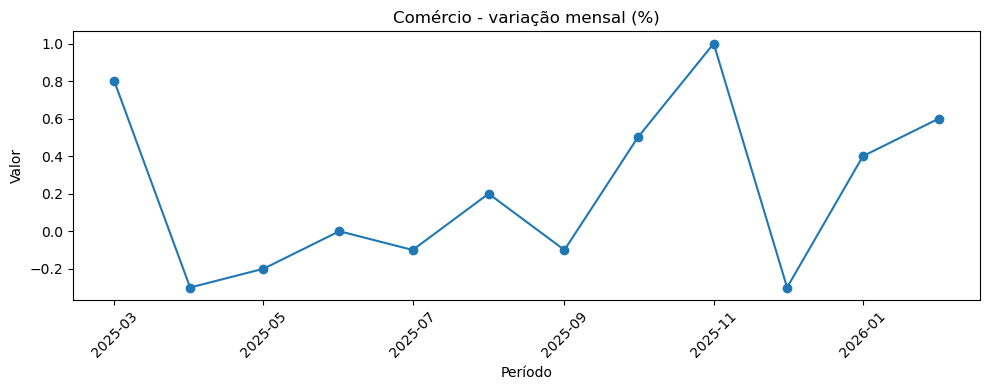

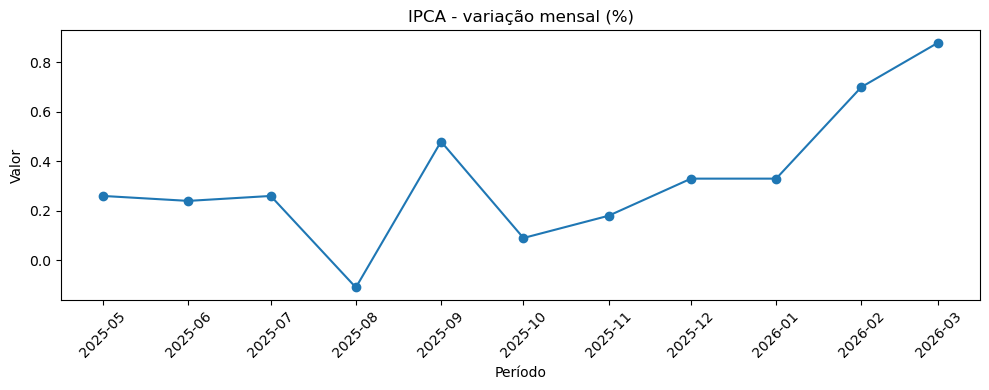

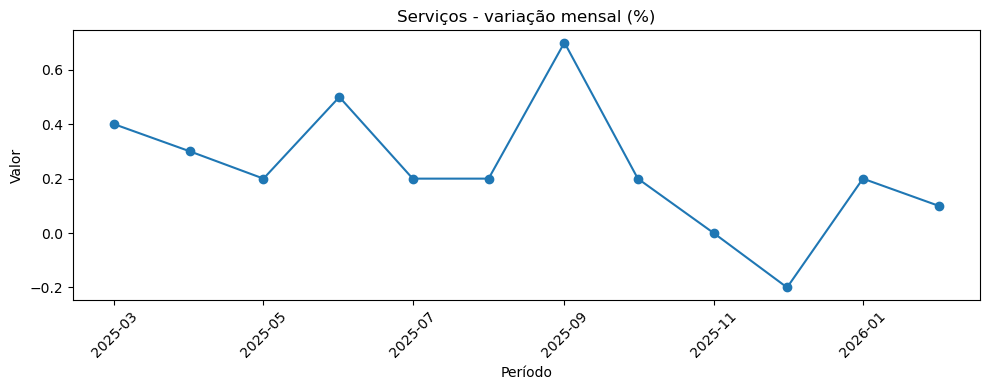

In [138]:
for indicador, subset in analysis_df.groupby("indicador"):
    plt.figure(figsize=(10, 4))
    plt.plot(subset["data_ref"], subset["valor"], marker="o")
    plt.title(SERIES_LABELS[indicador])
    plt.xlabel("Período")
    plt.ylabel("Valor")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Visualização 2 — Comparação das séries

Como todas as séries escolhidas estão em termos percentuais mensais, podemos compará-las diretamente em um mesmo gráfico.

### Leitura esperada
- o IPCA mostra a inflação mensal
- comércio e serviços mostram o ritmo recente da atividade
- diferenças entre as curvas podem sugerir desencontros entre consumo, serviços e preços

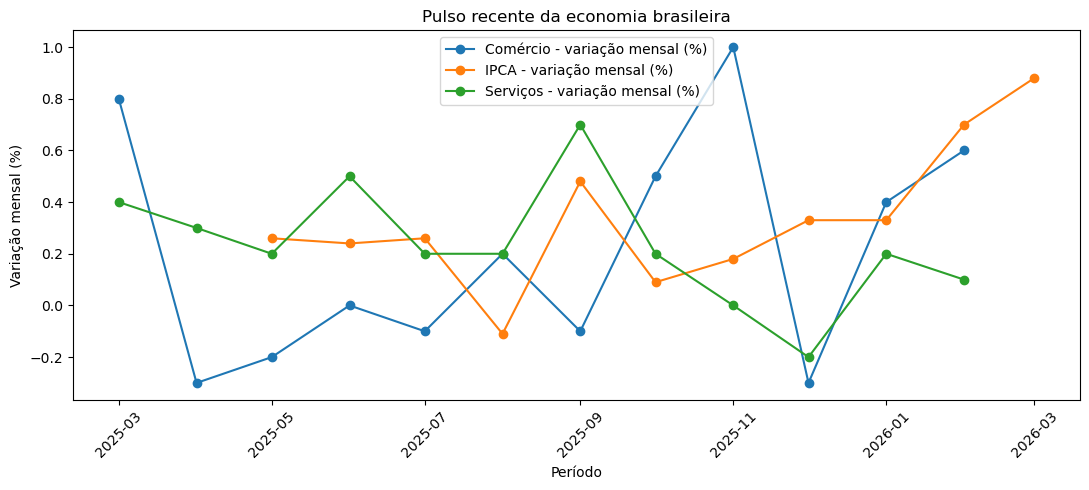

In [139]:
plt.figure(figsize=(11, 5))

for label, subset in analysis_df.groupby("serie_label"):
    plt.plot(subset["data_ref"], subset["valor"], marker="o", label=label)

plt.title("Pulso recente da economia brasileira")
plt.xlabel("Período")
plt.ylabel("Variação mensal (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Leitura quantitativa simples

Além do gráfico, vale destacar os valores mais recentes de cada série e compará-los com a média dos últimos 12 períodos.

In [140]:
latest_df = (
    analysis_df.sort_values("data_ref")
    .groupby(["indicador", "serie_label"], as_index=False)
    .tail(1)
    .rename(columns={"valor": "valor_mais_recente"})
)

mean_df = (
    analysis_df.groupby(["indicador", "serie_label"], as_index=False)["valor"]
    .mean()
    .rename(columns={"valor": "media_12m"})
)

reading_df = latest_df.merge(mean_df, on=["indicador", "serie_label"], how="left")
reading_df["dif_vs_media_12m"] = reading_df["valor_mais_recente"] - reading_df["media_12m"]

display(reading_df.sort_values("indicador"))

,indicador,serie_label,data_ref,valor_mais_recente,media_12m,dif_vs_media_12m
0,comercio,Comércio - variação mensal (%),2026-02-01,0.60,0.208333,0.391667
2,ipca,IPCA - variação mensal (%),2026-03-01,0.88,0.330909,0.549091
1,servicos,Serviços - variação mensal (%),2026-02-01,0.10,0.233333,-0.133333


## Anotações interpretativas

Nesta etapa, o objetivo é transformar os gráficos e a tabela-resumo em leitura de negócio, sem exagerar no escopo da análise.

### Leitura geral

O dado mais recente do **IPCA** ficou **acima da média dos últimos 12 meses**, o que reforça a percepção de uma inflação voltando a ganhar força no curto prazo.

No lado da atividade, o **comércio** mostrou um sinal mais claro de força, com resultado recente acima da média da própria série. Já os **serviços** permaneceram positivos, mas em ritmo mais moderado, sugerindo avanço com menos intensidade.

### O que os dados sugerem

- **IPCA:** sinal de pressão inflacionária mais forte no período mais recente.
- **Comércio:** atividade mais resiliente, com desempenho recente relativamente forte.
- **Serviços:** avanço mais contido, sem o mesmo fôlego observado no comércio.

### Possível desencontro entre inflação e atividade

Um dos pontos mais interessantes deste episódio é o contraste entre **inflação em aceleração** e **atividade ainda relativamente resistente**, especialmente no comércio.

Isso sugere um momento em que a economia não está parada, mas também não está confortável:
há movimento no consumo, porém em um ambiente de preços mais pressionado.

### Insight principal para o LinkedIn

> Os dados recentes sugerem um Brasil com consumo ainda resistente, serviços mais mornos e inflação novamente apertando o orçamento.

### Observação metodológica importante

Há uma pequena **janela temporal** entre os indicadores analisados neste episódio:

- o **IPCA** utilizado é de **março de 2026**
- **comércio** e **serviços** estão em **fevereiro de 2026**

Isso significa que este projeto deve ser lido como um **pulso recente da economia brasileira**, e não como uma fotografia perfeitamente sincronizada de um único mês.

### Registro pessoal da análise

Ao observar os gráficos e a tabela-resumo, a leitura mais consistente é a de uma economia com sinais mistos:
o consumo ainda mostra capacidade de reação, especialmente no varejo, enquanto a inflação volta a pesar mais no curto prazo.
Esse contraste é o principal valor interpretativo deste primeiro episódio.

## Conclusão do episódio

Neste primeiro episódio de **Fechando com Dados**, o objetivo não foi esgotar o tema da economia brasileira, e sim construir uma leitura inicial, clara e defensável com base em dados públicos recentes.

### Fechamento esperado

Ao final da análise, o principal sinal trazido pelos dados foi um contraste entre:

- **atividade ainda relativamente firme**
- **inflação mais pressionada no curto prazo**

Entre os indicadores observados, o **IPCA** foi o que mais chamou atenção, por apresentar valor recente acima da média dos últimos 12 meses. No campo da atividade, o **comércio** apareceu como o ponto mais forte da leitura, enquanto os **serviços** avançaram de forma mais moderada.

### O que essa leitura sugere sobre o momento recente

A leitura deste episódio sugere um momento em que:

- o consumo ainda apresenta alguma resiliência
- os serviços seguem crescendo, mas com menos intensidade
- a inflação volta a ganhar peso no presente

Em linguagem simples:
a economia não parece paralisada, mas também não está em terreno folgado.

### Limitações

Este episódio tem limitações importantes:

- recorte curto de **12 períodos**
- foco em apenas **três indicadores**
- leitura **exploratória**, sem modelagem causal ou previsão
- pequena defasagem temporal entre os dados analisados:
  - **IPCA de março de 2026**
  - **comércio e serviços de fevereiro de 2026**

Por isso, este projeto deve ser entendido como uma leitura de **janela recente**, e não como uma síntese fechada de toda a economia brasileira.

### Próximos passos possíveis

Nos próximos episódios, este estudo pode evoluir de várias formas:

- incluir uma nova fonte ou um novo indicador
- comparar o Brasil com recortes regionais
- investigar tendências em horizontes mais longos
- transformar a análise em uma versão pública para **portfólio** e **LinkedIn**

### Fechando com Dados

**Fechando com Dados #001** deixa um primeiro recado claro:

> Os dados recentes sugerem um Brasil em que o consumo ainda resiste, os serviços avançam com mais cautela e a inflação volta a pesar mais no presente.

Esse é o tipo de fechamento que dá sentido à proposta da série:
usar dados públicos atuais para construir análises simples, úteis e conectadas ao mundo real.

In [141]:
# Espaço opcional para salvar artefatos finais
summary_df.to_csv(DATA_DIR / "episodio_1_resumo_estatistico.csv", index=False, encoding="utf-8-sig")
reading_df.to_csv(DATA_DIR / "episodio_1_leitura_quantitativa.csv", index=False, encoding="utf-8-sig")

print("Arquivos finais salvos em:", DATA_DIR.resolve())

Arquivos finais salvos em: C:\Users\cco\OneDrive - Guanabara Diesel\0.Formação DSA\Z.Fechando com Dados\proj001\dados_fechando_com_dados_epi1
